# **MÓDULO 39 - Exercício - Aplicando XGBoost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
# Carregando a base
base = pd.read_csv('CARRO_CLIENTES.csv')

# Visualizando as primeiras linhas
base.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [3]:
# Verificando o tamanho da base
base.shape

(1000, 5)

In [4]:
# Verificando os tipos de dados
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   str  
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(4), str(1)
memory usage: 39.2 KB


In [5]:
# Verificando os dados nulos
# Verificando dados nulos
base.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [6]:
# Removendo a coluna ID
base = base.drop(columns=['User ID'])

# Conferindo a base após remover o ID
base.head()

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0


In [7]:
# Verificando dados estatísticos
base.describe()

,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000
mean,40.106000,72689.000000,0.402000
std,10.707073,34488.341867,0.490547
min,18.000000,15000.000000,0.000000
25%,32.000000,46375.000000,0.000000
50%,40.000000,72000.000000,0.000000
75%,48.000000,90000.000000,1.000000
max,63.000000,152500.000000,1.000000


A base possui 1000 registros e, inicialmente, 5 colunas. A coluna `User ID` foi removida por ser apenas um identificador, sem contribuição relevante para a previsão. Também foi verificado que a base não possui dados faltantes.

# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [8]:
# Aplicando Label Encoder na variável categórica Gender
label_encoder = LabelEncoder()

base['Gender_encoded'] = label_encoder.fit_transform(base['Gender'])

# Removendo a coluna categórica original
base = base.drop(columns=['Gender'])

# Visualizando a base transformada
base.head()

,Age,AnnualSalary,Purchased,Gender_encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1


In [9]:
# Verificando como as classes foram codificadas
for classe, codigo in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f'{classe}: {codigo}')

Female: 0
Male: 1


A variável categórica `Gender` foi transformada em variável numérica com Label Encoder. Após a codificação, a coluna original foi removida, mantendo apenas a versão numérica `Gender_encoded`.

# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

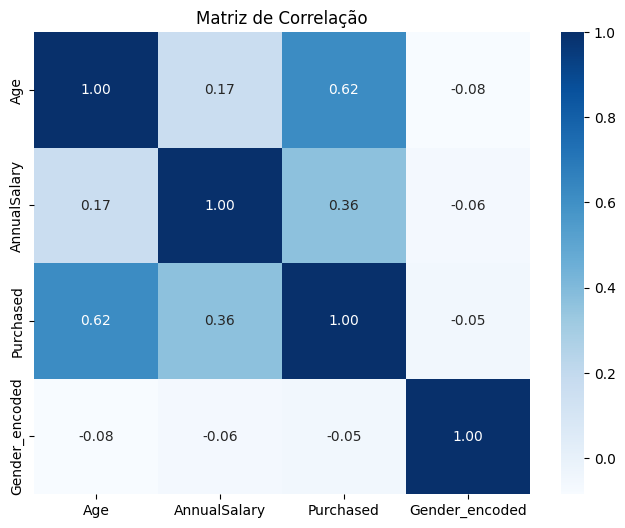

In [10]:
# Calculando a matriz de correlação
correlacao = base.corr()

# Plotando a matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

In [11]:
# Correlação das variáveis com a variável target
correlacao_target = correlacao['Purchased'].sort_values(ascending=False)

correlacao_target

Purchased         1.000000
Age               0.616036
AnnualSalary      0.364974
Gender_encoded   -0.047211
Name: Purchased, dtype: float64

A variável `Age` apresenta a maior correlação positiva com a variável target `Purchased`, indicando que a idade possui forte relação com a decisão de compra. A variável `AnnualSalary` também apresenta correlação positiva, porém menor. Já `Gender_encoded` possui baixa correlação com a variável alvo, sugerindo pouca influência direta na intenção de compra.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [12]:
# Separando a variável dependente Y e as variáveis independentes X
X = base.drop(columns=['Purchased'])
Y = base['Purchased']

In [13]:
# Separando em base de treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('Y_train:', Y_train.shape)
print('Y_test:', Y_test.shape)

X_train: (800, 3)
X_test: (200, 3)
Y_train: (800,)
Y_test: (200,)


A variável `Purchased` foi definida como variável dependente, pois representa se o cliente comprou ou não. As demais variáveis foram usadas como explicativas. A base foi separada em treino e teste, mantendo a proporção das classes com `stratify`.

# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [14]:
# Criando o modelo XGBoost com hiperparâmetros
model_xgboost = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=6,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Treinando o modelo
model_xgboost.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [15]:
# Verificando o objetivo do modelo
model_xgboost.objective

'binary:logistic'

Foi utilizado o `XGBClassifier`, pois o problema é de classificação binária: prever se o cliente comprou ou não. Os hiperparâmetros utilizados foram `max_depth`, `n_estimators` e `learning_rate`, seguindo a ideia apresentada na aula.

# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [16]:
# Previsões das classes
Y_pred = model_xgboost.predict(X_test)

# Probabilidades de cada classe
Y_pred_prob = model_xgboost.predict_proba(X_test)

In [17]:
# Visualizando as probabilidades
Y_pred_prob[:10]

array([[0.990896  , 0.00910401],
       [0.01525205, 0.98474795],
       [0.12336069, 0.8766393 ],
       [0.05822068, 0.9417793 ],
       [0.9987179 , 0.00128212],
       [0.99043304, 0.00956697],
       [0.08976543, 0.9102346 ],
       [0.08754832, 0.9124517 ],
       [0.99892014, 0.00107987],
       [0.99625605, 0.00374396]], dtype=float32)

In [18]:
# Criando um DataFrame com as probabilidades
probabilidades = pd.DataFrame({
    'Probabilidade_Nao_Comprou': Y_pred_prob[:, 0],
    'Probabilidade_Comprou': Y_pred_prob[:, 1]
})

probabilidades.head(10)

,Probabilidade_Nao_Comprou,Probabilidade_Comprou
0,0.990896,0.009104
1,0.015252,0.984748
2,0.123361,0.876639
3,0.058221,0.941779
4,0.998718,0.001282
5,0.990433,0.009567
6,0.089765,0.910235
7,0.087548,0.912452
8,0.998920,0.001080
9,0.996256,0.003744


O método `predict_proba` retorna a probabilidade de cada amostra pertencer a cada classe. Neste caso, a primeira coluna representa a probabilidade de não compra e a segunda coluna representa a probabilidade de compra.

# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

In [19]:
# Transformando as probabilidades em previsões binárias
Y_pred_binario = (Y_pred_prob[:, 1] >= 0.5).astype(int)

# Avaliando o modelo
accuracy = accuracy_score(Y_test, Y_pred_binario)
report = classification_report(Y_test, Y_pred_binario)
conf_matrix = confusion_matrix(Y_test, Y_pred_binario)

print(f'Acurácia: {accuracy}')
print('Relatório de Classificação:')
print(report)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.905
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       120
           1       0.90      0.86      0.88        80

    accuracy                           0.91       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.91      0.90       200

Matriz de Confusão:
[[112   8]
 [ 11  69]]


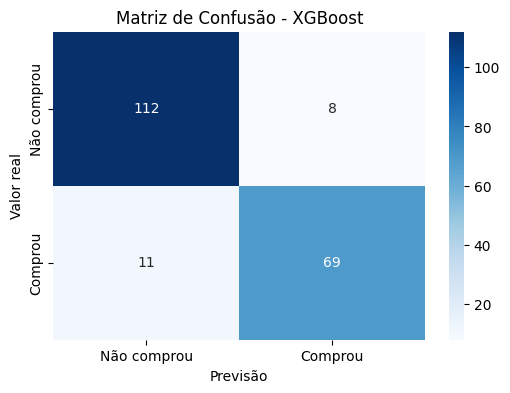

In [20]:
# Visualizando a matriz de confusão
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Não comprou', 'Comprou'],
    yticklabels=['Não comprou', 'Comprou']
)

plt.xlabel('Previsão')
plt.ylabel('Valor real')
plt.title('Matriz de Confusão - XGBoost')
plt.show()

As probabilidades foram transformadas em classes binárias usando o limite de 0.5. Assim, probabilidades maiores ou iguais a 0.5 foram classificadas como compra, enquanto valores menores foram classificados como não compra.

O modelo apresentou bom desempenho geral, conforme indicado pela acurácia e pelo relatório de classificação. A matriz de confusão permite observar os acertos e erros para as duas classes.

# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

In [21]:
# Obtendo a importância das variáveis com base no ganho
importances = model_xgboost.get_booster().get_score(importance_type='gain')

# Convertendo o dicionário de importâncias para DataFrame
importance_df = pd.DataFrame(
    list(importances.items()),
    columns=['Feature', 'Importance']
)

# Ordenando da maior para a menor importância
importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
0,Age,3.907190
1,AnnualSalary,2.240550
2,Gender_encoded,0.683882


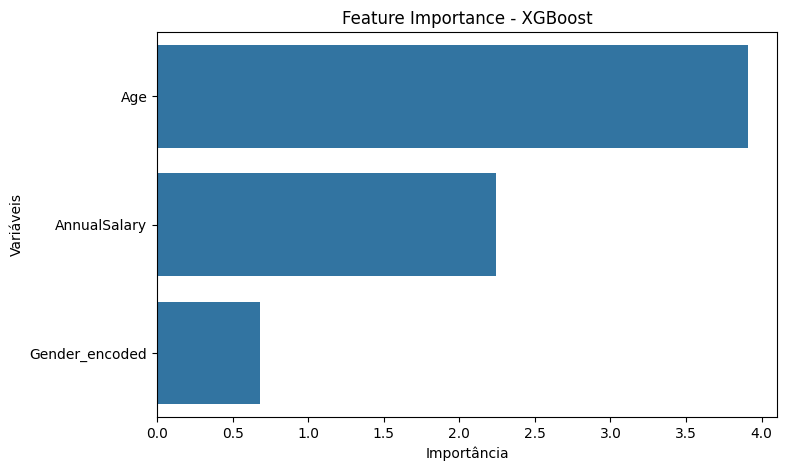

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - XGBoost')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.show()

A importância das variáveis foi calculada usando a métrica `gain`, que indica o quanto cada variável contribuiu, em média, para melhorar as divisões das árvores do modelo.

As variáveis mais importantes para o modelo foram `Age` e `AnnualSalary`, que também foram as variáveis com maior correlação com a variável target `Purchased`.

Isso mostra que, neste caso, existe coerência entre a análise de correlação e a importância das features no XGBoost. No entanto, a feature importance não depende apenas da correlação linear, pois o modelo também consegue capturar relações não lineares entre as variáveis.